In [16]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [17]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 
  
# metadata 
print(breast_cancer_wisconsin_diagnostic.metadata) 
  
# variable information 
print(breast_cancer_wisconsin_diagnostic.variables) 


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [19]:
# 1. Define the custom Logistic Regression class FIRST
#    (must exist before you try to instantiate it)
class BreastCancerLogisticRegression:
    def __init__(self, learning_rate=0.01, epochs=10000, tolerance=1e-7):
        self.lr = learning_rate
        self.epochs = epochs
        self.tolerance = tolerance
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for epoch in range(self.epochs):
            z = np.dot(X, self.weights) + self.bias
            y_pred = self._sigmoid(z)

            eps = 1e-15
            y_pred_clipped = np.clip(y_pred, eps, 1 - eps)
            loss = -(1 / n_samples) * np.sum(
                y * np.log(y_pred_clipped) + (1 - y) * np.log(1 - y_pred_clipped)
            )
            self.loss_history.append(loss)

            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            if epoch > 0 and abs(self.loss_history[-2] - self.loss_history[-1]) < self.tolerance:
                print(f"-> Model converged early at epoch {epoch}!")
                break

    def predict_proba(self, X):
        # renamed from predict_prob -> predict_proba to match sklearn convention
        # and to match how it's called later in the script
        z = np.dot(X, self.weights) + self.bias
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        probabilities = self.predict_proba(X)
        return np.where(probabilities >= threshold, 1, 0)


In [20]:
# 2. Load dataset
data = load_breast_cancer()
X = data.data
y = data.target  # 0 = malignant, 1 = benign (per data.target_names order)

df = pd.DataFrame(X, columns=data.feature_names)
print(df.head())
print("\nTarget Classes:", data.target_names)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [21]:
# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
# 4. Feature scaling (essential — gradient descent will barely move
#    without it, since raw features range from ~0.05 to ~2500)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
# 5. Create and train the model
model = BreastCancerLogisticRegression(learning_rate=0.01, epochs=10000, tolerance=1e-7)
model.fit(X_train, y_train)

In [24]:
# 6. Predictions
y_pred = model.predict(X_test)
probability = model.predict_proba(X_test)

print("\nPredicted Probabilities (first 5):")
print(probability[:5])



Predicted Probabilities (first 5):
[8.97391529e-01 2.09654999e-05 4.16414980e-03 9.98783687e-01
 9.99901727e-01]


In [25]:
# 7. Metrics
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))


Accuracy: 0.9824561403508771

Confusion Matrix:
[[42  1]
 [ 1 70]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        43
      benign       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



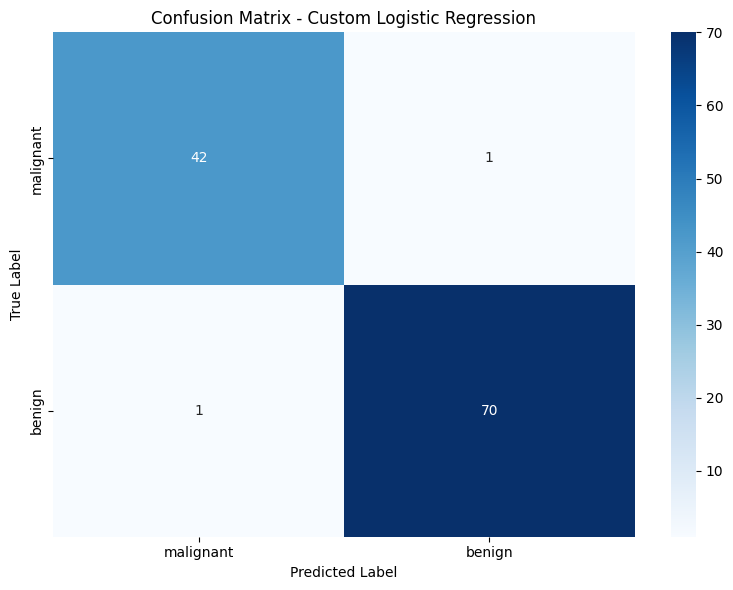

In [26]:
# 8. Confusion matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
    xticklabels=data.target_names, yticklabels=data.target_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Custom Logistic Regression')
plt.tight_layout()
plt.savefig("custom_logreg_confusion_matrix.png", dpi=150)
plt.show()

In [27]:
# 9. Inspect weights/bias (NOT coef_/intercept_ — this is a custom
#    class, not sklearn, so it doesn't have those attribute names)
print("\nBias (intercept):", model.bias)
print("\nWeights (coefficients):")
print(model.weights)


Bias (intercept): 0.5606498103927213

Weights (coefficients):
[-0.53890572 -0.64318343 -0.51733806 -0.57656667 -0.20070232  0.17902942
 -0.63270053 -0.78100823  0.03099855  0.2995162  -0.89773723  0.05843337
 -0.6158381  -0.69424543 -0.17847102  0.59638537  0.07479842 -0.13546733
  0.30710062  0.53064702 -0.81898863 -1.02841216 -0.70655051 -0.79329148
 -0.69215679 -0.13326485 -0.72125649 -0.7538339  -0.84800444 -0.13536757]


In [28]:
# Single-sample sanity check.
# NOTE: np.dot of two 1D arrays returns a scalar float, not an array,
# so don't index it with z[0] later — that was a bug in the original.
sample = X_test[0]
z = np.dot(model.weights, sample) + model.bias
print("\nz value:", z)

prob = 1 / (1 + np.exp(-z))
print("Probability:", prob)


z value: 2.1685717598529597
Probability: 0.8973915288645342


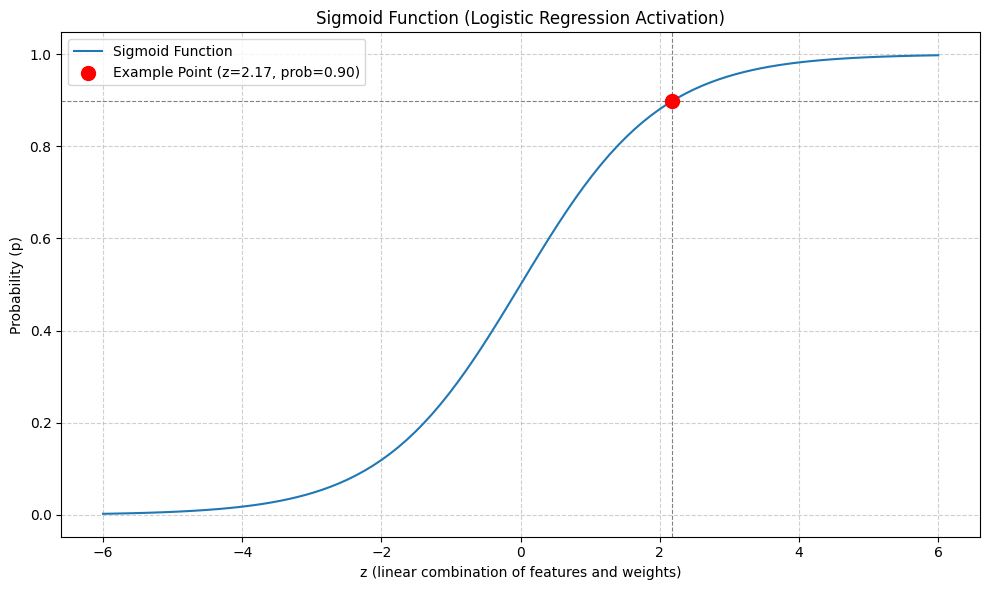

In [29]:
# 10. Sigmoid curve with the example point highlighted
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_values = np.linspace(-6, 6, 100)
sigmoid_probs = sigmoid(z_values)

plt.figure(figsize=(10, 6))
plt.plot(z_values, sigmoid_probs, label='Sigmoid Function')
plt.scatter(z, prob, color='red', s=100, zorder=5, label=f'Example Point (z={z:.2f}, prob={prob:.2f})')
plt.axvline(x=z, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(y=prob, color='gray', linestyle='--', linewidth=0.8)
plt.title('Sigmoid Function (Logistic Regression Activation)')
plt.xlabel('z (linear combination of features and weights)')
plt.ylabel('Probability (p)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("sigmoid_example_point.png", dpi=150)
plt.show()


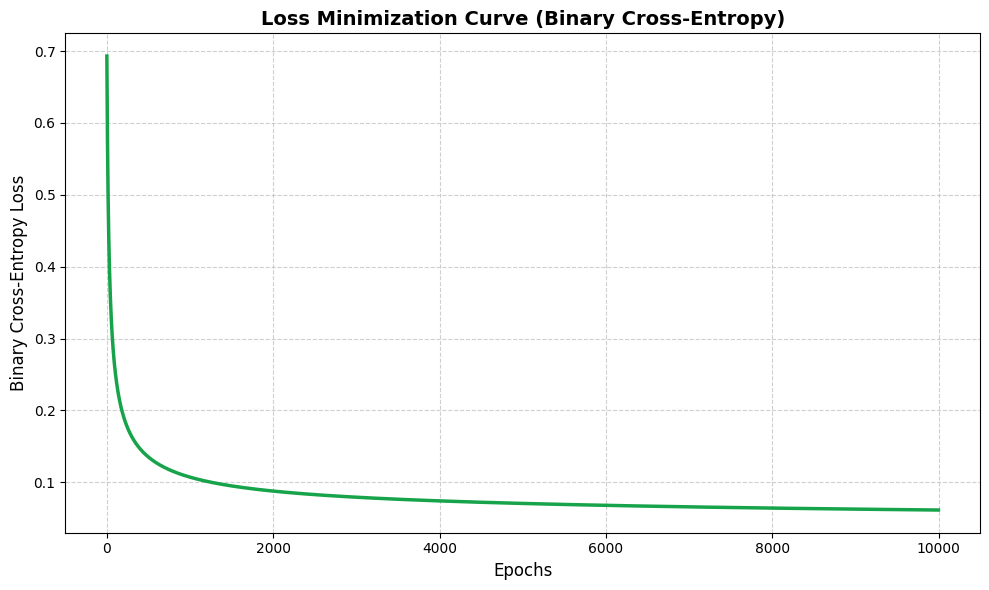

In [30]:
# 11. Loss curve over training epochs
plt.figure(figsize=(10, 6))
plt.plot(model.loss_history, color='#16a34a', linewidth=2.5)
plt.title("Loss Minimization Curve (Binary Cross-Entropy)", fontsize=14, fontweight='bold')
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Binary Cross-Entropy Loss", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()


In [ ]:
#1. Accuracy — 98.25%
#2. Precision — 0.98 (malignant), 0.99 (benign)
#3. Recall — 0.98 (malignant), 0.99 (benign)
#4. Confusion matrix — the part that actually matters clinically
#5. F1 Score — 0.98 for both classes
#6. Loss curve
#7. Sigmoid example point (z ≈ 2.17, probability ≈ 0.897)
#8. Coefficients (weights)
